# Analysis of Medicare Income-Related Monthly Adjustment Amounts

This notebook explores the idea that "IRMAA doesn't matter" -- at least not enough to
let it drive your retirement income plan. That idea was championed by Patrick King
in [this YouTube video](https://www.youtube.com/watch?v=kZZ5LoJSqfY).

The basic idea is that, while IRMAA thresholds are "cliffs", the actual amounts are small in
comparison to income or federal income taxes.

This notebook looks specifically at the _marginal_ rates of Federal Income tax and IRMAA.

The marginal Federal Income tax rates are easy -- we can just read them from the tax tables.
Though this is a bit simplistic because when it is only accurate when the marginal dollar
is earned income. The marginal rate will be lower if the marginal dollar comes from dividends,
capital gains, or some possibly some other source. But here we use the marginal rates on earned
income just to keep things easy.

For marginal IRMAA rate, we look at the rate paid on the income that exceeds the relevant
threshold. So the first dollar over the threshold has an astronomical marginal rate, but this
rate drops quickly as income increases.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


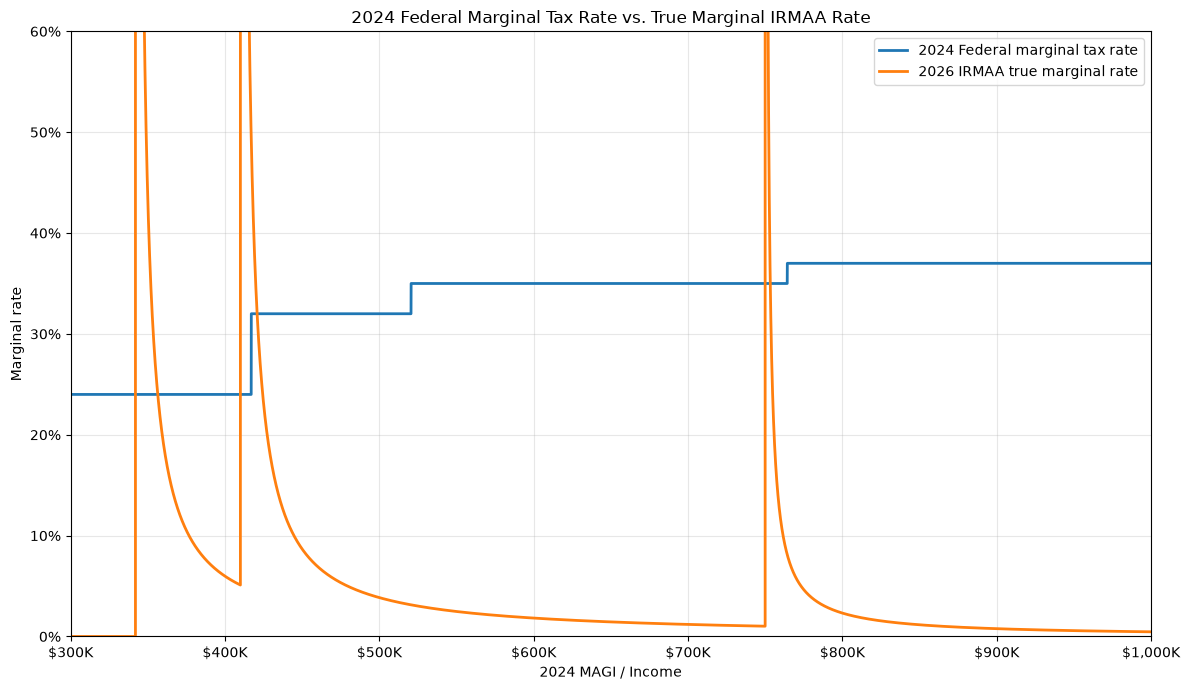

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2024 Federal marginal tax rate
# Married Filing Jointly, both spouses age 65+
#
# Additional standard deduction for two spouses age 65+:
# $1,950 x 2 = $3,900
# Base MFJ standard deduction: $29,200
# Total standard deduction: $33,100
# ------------------------------------------------------------

standard_deduction = 33100

# 2024 MFJ taxable-income brackets
tax_brackets = [
    (23200, 0.10),
    (94300, 0.12),
    (201050, 0.22),
    (383900, 0.24),
    (487450, 0.32),
    (731200, 0.35),
    (float("inf"), 0.37),
]

def federal_marginal_rate(income):
    taxable_income = max(0, income - standard_deduction)

    for threshold, rate in tax_brackets:
        if taxable_income <= threshold:
            return rate

    return 0.37


# ------------------------------------------------------------
# 2026 IRMAA
#
# Based on 2024 MAGI
# Married Filing Jointly
# Both spouses on Medicare
#
# These are the combined annual Part B + Part D increases
# for the couple when crossing each threshold.
#
# Threshold       Annual increase for couple
# $342,000        $3,470.40
# $410,000        $3,470.40
# $750,000        $1,161.60
# ------------------------------------------------------------

irmaa_thresholds = {
    342000: 3470.40,
    410000: 3470.40,
    750000: 1161.60,
}

def irmaa_marginal_rate(income):
    """Return the IRMAA increase divided by income above the latest threshold."""
    applicable_thresholds = [
        threshold
        for threshold in irmaa_thresholds
        if threshold < income
    ]

    if not applicable_thresholds:
        return 0

    threshold = max(applicable_thresholds)
    increase = irmaa_thresholds[threshold]
    return increase / (income - threshold)


# ------------------------------------------------------------
# Generate data
# ------------------------------------------------------------

incomes = list(range(300000, 1000001))

tax_rates = [
    federal_marginal_rate(income)
    for income in incomes
]

irmaa_rates = [
    irmaa_marginal_rate(income)
    for income in incomes
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    incomes,
    tax_rates,
    label="2024 Federal marginal tax rate",
    linewidth=2
)

ax.plot(
    incomes,
    irmaa_rates,
    label="2026 IRMAA true marginal rate",
    linewidth=2
)

ax.set_xlim(300000, 1000000)

# Change this to experiment with the vertical scale.
# 0.60 = 60%
ax.set_ylim(0, 0.60)

ax.set_xlabel("2024 MAGI")
ax.set_ylabel("Marginal rate")

ax.set_title(
    "2024 Federal Marginal Tax Rate vs. True Marginal IRMAA Rate"
)

ax.grid(True, alpha=0.3)
ax.legend()

# Format X axis as dollars
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}K")
)

# Format Y axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, p: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

The graph gives the overall picture, but lets zoom in on a few points to really illustrate the idea.

- At income of $409,999 (just under the $410,000 threshold)
  - Marginal Federal income tax rate is 24%
  - Marginal IRMAA rate is (3770.40/(409,999-342,000)) = 5.5%
- At income of $478,000 ($68K above the $410K threshold)
  - Marginal Federal income tax rate is 32%
  - Marginal IRMAA rate is (3770.40/(478,000-410,000)) = 5.5%

The difference between these two points from the perspective of marginal rates is only due to the higher marginal Federal Income tax rate.
From $478K up to $749,999, the marginal IRMAA rate is actually _lower_ than for any income above $218K.

You probably _do_ want to be careful to not tip over just a little into the next IRMAA bracket.
But you should not feel constrained to stay under a particular threshold if it makes sense to go well above it.